In [156]:
import pandas as pd
import numpy as np

In [210]:
df = pd.read_csv(
    'D:/ml/positive_negative_messages.csv',header=None,skiprows=1,sep=';',names=['A','B'])

In [212]:
df

,A,B
0,Words cannot describe how much I love you. You...,"1,,"
1,I never thought perfect men exist until I met ...,"1,,,"
2,You are my power.,"1,,,"
3,I cannot imagine my life without you.,"1,,,"
4,I can count myself lucky for having found you.,"1,,,"
...,...,...
192,You have ruined my life.,"0,,,"
193,"It is over. It was not love, it was only a bu...","0,,"
194,I will celebrate the day of our divorce.,"0,,,"
195,I hope we will never meet again. Loving you w...,"0,,,"


In [214]:
df['B'].unique()
df.info()
df

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 197 entries, 0 to 196
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   A       197 non-null    object
 1   B       197 non-null    object
dtypes: object(2)
memory usage: 3.2+ KB


,A,B
0,Words cannot describe how much I love you. You...,"1,,"
1,I never thought perfect men exist until I met ...,"1,,,"
2,You are my power.,"1,,,"
3,I cannot imagine my life without you.,"1,,,"
4,I can count myself lucky for having found you.,"1,,,"
...,...,...
192,You have ruined my life.,"0,,,"
193,"It is over. It was not love, it was only a bu...","0,,"
194,I will celebrate the day of our divorce.,"0,,,"
195,I hope we will never meet again. Loving you w...,"0,,,"


In [216]:
df['B'] = df['B'].str.replace(',', '', regex=False)
df['B'] = df['B'].astype(int)

In [220]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 197 entries, 0 to 196
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   A       197 non-null    object
 1   B       197 non-null    int32 
dtypes: int32(1), object(1)
memory usage: 2.4+ KB


In [222]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import LabelEncoder

In [224]:
vectorizer= TfidfVectorizer()
X=vectorizer.fit_transform(df['A'])

In [226]:
print("Vocabulary:", vectorizer.vocabulary_)
print("IDF values:", vectorizer.idf_)
print("Features:", vectorizer.get_feature_names_out())

Vocabulary: {'words': 454, 'cannot': 66, 'describe': 100, 'how': 197, 'much': 283, 'love': 253, 'you': 462, 'are': 27, 'the': 400, 'sun': 391, 'of': 298, 'my': 285, 'life': 238, 'only': 303, 'thing': 402, 'that': 399, 'keeps': 222, 'me': 265, 'alive': 9, 'never': 291, 'thought': 406, 'perfect': 319, 'men': 268, 'exist': 137, 'until': 423, 'met': 270, 'power': 328, 'imagine': 203, 'without': 450, 'can': 65, 'count': 87, 'myself': 286, 'lucky': 257, 'for': 154, 'having': 188, 'found': 158, 'everything': 136, 'matters': 263, 'to': 409, 'one': 302, 'and': 16, 'adore': 2, 'running': 359, 'all': 10, 'want': 433, 'from': 162, 'christmas': 77, 'easter': 119, 'days': 93, 'in': 206, 'year': 459, 'is': 216, 'we': 437, 'should': 368, 'be': 37, 'together': 412, 'end': 128, 'our': 308, 'no': 293, 'other': 307, 'than': 397, 'would': 458, 'ruin': 356, 'left': 233, 'minute': 273, 'ago': 7, 'already': 12, 'feel': 151, 'lonely': 247, 'with': 449, 'smile': 372, 'time': 408, 'make': 258, 'stronger': 388, '

In [228]:
x_train, x_test, y_train, y_test= train_test_split(df['A'],df['B'],test_size =0.1,random_state=1)

In [230]:
model = make_pipeline(TfidfVectorizer(),MultinomialNB())

In [232]:
model.fit(x_train,y_train)

Pipeline(steps=[('tfidfvectorizer', TfidfVectorizer()),
                ('multinomialnb', MultinomialNB())])

In [234]:
y_pred= model.predict(x_test)
y_pred

array([1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1])

In [236]:
from sklearn.metrics import classification_report

In [238]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.78      1.00      0.88         7
           1       1.00      0.85      0.92        13

    accuracy                           0.90        20
   macro avg       0.89      0.92      0.90        20
weighted avg       0.92      0.90      0.90        20



In [240]:
def category_predict(s,model=model):
    pred_cat=model.predict([s])[0]
    return pred_cat

In [242]:
category_predict('it is a wonderful day')

0

In [244]:
category_predict('you are cheating')

0

In [246]:
category_predict('This guy is evil, he intentionally slapped the kid who was playing with his toys')

0

In [248]:
category_predict('I am evil')  ## limitation of Tfidf- it does not understand the grammar and sentiments, instead learn vocabulary
                                # so if evil which is a negative word and in actual dataset it is rare word and used in positive sentence accordingly it IDF value is decided
                                

1

In [250]:
category_predict('he is a disgusting guy')

0

In [252]:
category_predict('he speaks behind people back')

0

In [256]:
category_predict('smoking is a bad habit')

0

In [258]:
category_predict('looking back i recall only good memories')

1

In [260]:
category_predict('hitting gym increases life expectancy')

1

In [262]:
category_predict('you are rude to my mom but you love me very much')

1

In [266]:
category_predict('i hate you')

0

In [268]:
category_predict('i love you')

1

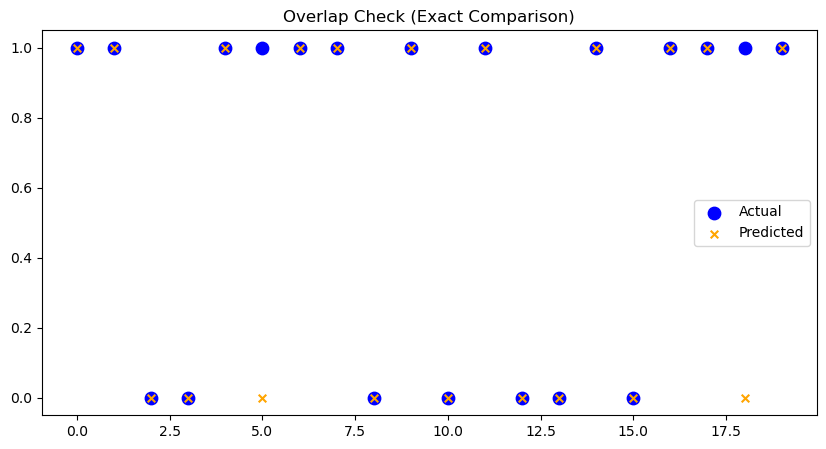

In [278]:
import numpy as np
import matplotlib.pyplot as plt

x = np.arange(len(y_test))

plt.figure(figsize=(10,5))

plt.scatter(x, y_test, color='blue', label='Actual', s=80)
plt.scatter(x, y_pred, color='orange', label='Predicted', s=30, marker='x')

plt.legend()
plt.title("Overlap Check (Exact Comparison)")
plt.show()